# Getting data

### Setup

In [251]:
import pandas as pd
import seaborn as sns
import sqlite3

In [252]:
import os
os.getcwd()

'/home/f5b70555-e080-4a9b-a402-13053ac1b7a2/MURACH/DATA-CLEANING/my-class-exercises'

## CSV Files

###  Read a CSV into a DataFrame directly from a web URL

In [253]:
mortality_url = "https://www.murach.com/python_analysis/mortality.csv"
mortality_data = pd.read_csv(mortality_url)

In [254]:
mortality_data

,Year,Age Group,Death Rate
0,1900,1-4 Years,1983.8
1,1901,1-4 Years,1695.0
2,1902,1-4 Years,1655.7
3,1903,1-4 Years,1542.1
4,1904,1-4 Years,1591.5
...,...,...,...
471,2014,15-19 Years,45.5
472,2015,15-19 Years,48.3
473,2016,15-19 Years,51.2
474,2017,15-19 Years,51.5


###  Downloading a file to disk before loading it into a DataFrame

In [255]:
from urllib import request
polls_url = 'https://www.murach.com/python_analysis/president_polls_2016.csv'
request.urlretrieve(polls_url, filename='president_polls_2016.csv')

('president_polls_2016.csv', <http.client.HTTPMessage at 0x77ec4af86d50>)

In [256]:
polls = pd.read_csv('president_polls_2016.csv')
polls.head(2)

,cycle,branch,type,matchup,forecastdate,state,startdate,enddate,pollster,grade,...,adjpoll_clinton,adjpoll_trump,adjpoll_johnson,adjpoll_mcmullin,multiversions,url,poll_id,question_id,createddate,timestamp
0,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/2016,U.S.,11/3/2016,11/6/2016,ABC News/Washington Post,A+,...,45.20163,41.72430,4.626221,NaN,NaN,https://www.washingtonpost.com/news/the-fix/wp...,48630,76192,11/7/2016,11/8/2016 9:35
1,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/2016,U.S.,11/1/2016,11/7/2016,Google Consumer Surveys,B,...,43.34557,41.21439,5.175792,NaN,NaN,https://datastudio.google.com/u/0/#/org//repor...,48847,76443,11/7/2016,11/8/2016 9:35


## Databases

### The Movie Database:  Table Structure

### How to run queries against a database

### List all the actors in the actors table

In [257]:
movies_con = sqlite3.connect('../data/MovieDb.sqlite')
movies_cur = movies_con.cursor()
movies_cur.execute(
    'SELECT * FROM directors').fetchall()

[(1, 'Steven Spielberg'),
 (2, 'Tony Scott'),
 (3, 'Barry Levinson'),
 (4, 'Rob Reiner'),
 (5, 'Nora Ephron'),
 (6, 'Robert Zemeckis'),
 (7, 'Robert Benton'),
 (8, 'Paul Brickman'),
 (9, 'Mike Nichols'),
 (10, 'Penny Marshall')]

### Get information about a table

In [258]:
movies_cur.execute('PRAGMA table_info(actors)').fetchall()

[(0, 'id', 'INTEGER', 0, None, 0), (1, 'name', 'TEXT', 0, None, 0)]

### Import the data from a simple query into a DataFrame (Single Table)

In [259]:
movies = pd.read_sql_query(
    '''SELECT name
    FROM actors''', movies_con)
movies.head(10)

,name
0,Andy Serkis
1,Anne Bancroft
2,Anthony Edwards
3,Ariana Richards
4,BD Wong
5,Billy Crystal
6,Bob Odenkirk
7,Bob Peck
8,Bradley Whitford
9,Bruce Greenwood


### Join multiple tables and import into a DataFrame

In [260]:
moviedirector = pd.read_sql_query(
    '''SELECT release_date AS "Release Date", title AS "Title", directors.name AS "Director", budget AS "Budget"
       FROM movies
    JOIN directors ON movies.director_id = directors.id''', movies_con)
moviedirector.head(5)

,Release Date,Title,Director,Budget
0,1986,Top Gun,Tony Scott,15000000.0
1,1989,When Harry Met Sally,Rob Reiner,16000000.0
2,1988,Rain Man,Barry Levinson,25000000.0
3,1988,You've Got Mail,Nora Ephron,65000000.0
4,1994,Forest Gump,Robert Zemeckis,55000000.0


# Cleaning Data

### Types of problems with data
- Duplicate rows
- Rows that are not needed
- Columns that are not needed
- Rename the columns so easier to understand
- Missing values
- Wrong data types like numbers that are imported as strings
- Find and fix outliers

### Setup

##### Note:  We will overwrite the previous version of the mortality data

In [261]:
mortality_data = pd.read_csv('../data/mortality.csv')
mortality_data.columns = mortality_data.columns.str.replace(" ", "")
mortality_data.AgeGroup = mortality_data.AgeGroup.replace( {'1-4 Years':'01-04 Years','5-9 Years':'05-09 Years'})
mortality_data['MeanCentered'] = mortality_data.DeathRate - mortality_data.DeathRate.mean()

In [262]:
mortality_data.head()

,Year,AgeGroup,DeathRate,MeanCentered
0,1900,01-04 Years,1983.8,1790.87584
1,1901,01-04 Years,1695.0,1502.07584
2,1902,01-04 Years,1655.7,1462.77584
3,1903,01-04 Years,1542.1,1349.17584
4,1904,01-04 Years,1591.5,1398.57584


In [263]:
mortality_data.tail()

,Year,AgeGroup,DeathRate,MeanCentered
471,2014,15-19 Years,45.5,-147.42416
472,2015,15-19 Years,48.3,-144.62416
473,2016,15-19 Years,51.2,-141.72416
474,2017,15-19 Years,51.5,-141.42416
475,2018,15-19 Years,49.2,-143.72416


### Load the mortality data to be cleaned 

### Summary of problems
####  NOTE This is a version of the dataset created by me.  This is not part of the textbook materials.  

###### Note: The header is row 1
- There is a column (Current date) that is not needed.  This might be analogous to a metadata time stamp for when the data was collected.
- Data type of the year column
- One of the "Age Group" values has a typo.
- There are 5 missing values for DeathRate at index 9, 19, 29, 39, 49
- Row 68 - 69 (year 1966):  duplicate row
- Row 87 - Row 89:  duplicate rows
- Row 212: invalid numeric data
- Row 250: invalid string data in the DeathRate cell


##### NOTE:  Dropping the "Mean Centered" column because this fails with invalid data types.
- This data would need to be cleaned before adding this column
- We can add it back later after the data is cleaned.

In [264]:
mortality2clean = pd.read_csv('../data/mymortality-messy.csv')
mortality2clean.columns = mortality2clean.columns.str.replace(" ", "")
mortality2clean.AgeGroup = mortality2clean.AgeGroup.replace( {'1-4 Years':'01-04 Years','5-9 Years':'05-09 Years'})
# mortality2clean['MeanCentered'] = mortality2clean.DeathRate - mortality2clean.DeathRate.mean()

In [265]:
mortality2clean.head(5)

,Year,AgeGroup,DeathRate,CurrentDate
0,1900,1-4 years,1983.8,6/20/2025
1,1901,01-04 Years,1695,6/21/2025
2,1902,01-04 Years,1655.7,6/22/2025
3,1903,01-04 Years,1542.1,6/23/2025
4,1904,01-04 Years,1591.5,6/24/2025


### (Optional) Compare with the other data sets too 
#####  These take a while to load, so uncomment when you are ready, but have coffee nearby. 

##### Optional data sets (uncomment below to use)
- Polls
- Jobs

 

In [266]:
# This takes a really long time to run
# polls = pd.read_csv('../data/president_polls_2016.csv')

In [267]:
# This takes a really long time to run
# jobs = pd.read_excel('../data/all_data_M_2018.xlsx')

In [268]:
#polls.head(3)

In [269]:
# jobs.head(3)

### Run info() on both the original data (cleaned) and the version that needs to be cleaned
##### Compare the results
- mortality (original)
- mortality (needs to be cleaned) 

#### Mortality (orignal)

In [270]:
mortality_data.info(verbose=True, memory_usage='deep', show_counts=True)                

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          476 non-null    int64  
 1   AgeGroup      476 non-null    object 
 2   DeathRate     476 non-null    float64
 3   MeanCentered  476 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 42.9 KB


In [271]:
mortality_data.nunique()

Year            119
AgeGroup          4
DeathRate       430
MeanCentered    430
dtype: int64

- Returns each unique value in a column

In [272]:
mortality_data.Year.value_counts().head(10)

Year
1900    4
1975    4
1987    4
1986    4
1985    4
1984    4
1983    4
1982    4
1981    4
1980    4
Name: count, dtype: int64

#### Mortality (To Clean)

In [273]:
mortality2clean.info(verbose=True, memory_usage='deep', show_counts=True)          

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 483 entries, 0 to 482
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Year         483 non-null    int64 
 1   AgeGroup     483 non-null    object
 2   DeathRate    478 non-null    object
 3   CurrentDate  483 non-null    object
dtypes: int64(1), object(3)
memory usage: 95.8 KB


#### NOTE
- We can see the extra columns (column that simulate timestamp metadata)
- Notice "AgeGroup."  One of the data points in "Age Group" has a typo, "Years" vs. "years."

In [274]:
mortality2clean.nunique()

Year           119
AgeGroup         5
DeathRate      425
CurrentDate    443
dtype: int64

#### NOTE
- Each year should have a count of 4 (representing the 4 valid age groups)

In [275]:
mortality2clean.Year.value_counts().head(10)

Year
1984    10
1966     5
1900     4
1975     4
1987     4
1986     4
1985     4
1983     4
1982     4
1981     4
Name: count, dtype: int64

### Drop Duplicated Rows
- This is a little tricky because the year 1966 for Age Group 1 to 4 years is also a duplicated row, but the extra column (which has different dates (timestamps) for these two years, makes it appear like it is how a duplicate.
- We want to see what this looks like after we drop the CurrentDate column.

In [276]:
mortality2clean[mortality2clean.duplicated(keep=False)]

,Year,AgeGroup,DeathRate,CurrentDate
444,1984,15-19 Years,80.4,9/30/2023
445,1984,15-19 Years,80.4,9/30/2023
446,1984,15-19 Years,80.4,9/30/2023
447,1984,15-19 Years,80.4,9/30/2023
448,1984,15-19 Years,80.4,9/30/2023


#### Find unwanted columns
- Use the nunique() method to find unwanted columns and then drop them.

In [277]:
mortality2clean.nunique()

Year           119
AgeGroup         5
DeathRate      425
CurrentDate    443
dtype: int64

In [278]:
mortality2clean = mortality2clean.drop(columns=['CurrentDate'])
mortality2clean.nunique()

Year         119
AgeGroup       5
DeathRate    425
dtype: int64

#### Now we get a better view of duplicated rows
- Try running the duplicate method again
- Now we see the duplicated rows in year 1966

In [279]:
mortality2clean[mortality2clean.duplicated(keep=False)]

,Year,AgeGroup,DeathRate
66,1966,01-04 Years,96.4
67,1966,01-04 Years,96.4
85,1984,01-04 Years,52.2
86,1984,01-04 Years,52.2
87,1984,01-04 Years,52.2
444,1984,15-19 Years,80.4
445,1984,15-19 Years,80.4
446,1984,15-19 Years,80.4
447,1984,15-19 Years,80.4
448,1984,15-19 Years,80.4


#### Drop duplicated rows and verify
- Drop the duplicated rows

In [280]:
mortality2clean = mortality2clean.drop_duplicates(keep='first')

- The duplicated rows are gone

In [281]:
mortality2clean[mortality2clean.duplicated(keep=False)]

,Year,AgeGroup,DeathRate


### Find Missing Values
- Look for some missing values (eyeball)
- In this dataset, there are 5  missing values every 10 rows starting at index 9
- The only missing values are in the DeathRate column.
- You can try experimenting with deleting values in the Year or AgeGroup column. 

In [282]:
mortality2clean.head(10)

,Year,AgeGroup,DeathRate
0,1900,1-4 years,1983.8
1,1901,01-04 Years,1695
2,1902,01-04 Years,1655.7
3,1903,01-04 Years,1542.1
4,1904,01-04 Years,1591.5
5,1905,01-04 Years,1498.9
6,1906,01-04 Years,1580
7,1907,01-04 Years,1468.3
8,1908,01-04 Years,1396.8
9,1909,01-04 Years,NaN


### Review:  selecting rows
- Let's take a moment to review different ways to select rows in a dataframe

##### Print out a range of rows (not head or tail)

In [283]:
mortality2clean.loc[9:19]

,Year,AgeGroup,DeathRate
9,1909,01-04 Years,NaN
10,1910,01-04 Years,1397.3
11,1911,01-04 Years,1176
12,1912,01-04 Years,1094.1
13,1913,01-04 Years,1193.4
14,1914,01-04 Years,1024.2
15,1915,01-04 Years,924.2
16,1916,01-04 Years,1111.5
17,1917,01-04 Years,1066
18,1918,01-04 Years,1573.5


##### Provide a list of rows (to verify)

In [284]:
mortality2clean.loc[[9,19,29,39,49]]

,Year,AgeGroup,DeathRate
9,1909,01-04 Years,NaN
19,1919,01-04 Years,NaN
29,1929,01-04 Years,NaN
39,1939,01-04 Years,NaN
49,1949,01-04 Years,NaN


In [285]:
mortality2clean.loc[9:49:10]

,Year,AgeGroup,DeathRate
9,1909,01-04 Years,NaN
19,1919,01-04 Years,NaN
29,1929,01-04 Years,NaN
39,1939,01-04 Years,NaN
49,1949,01-04 Years,NaN


##### WARNING: The command below will fail unless the type of the DeathRate value is float64.  

In [286]:
# mortality2clean.loc[mortality2clean.DeathRate > 1000]
mortality2clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 476 entries, 0 to 482
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       476 non-null    int64 
 1   AgeGroup   476 non-null    object
 2   DeathRate  471 non-null    object
dtypes: int64(1), object(2)
memory usage: 31.0+ KB


In [287]:
missing_count = mortality2clean.shape[0] - mortality2clean.count()
print(missing_count)

Year         0
AgeGroup     0
DeathRate    5
dtype: int64


In [288]:
mortality2clean[mortality2clean.isnull().any(axis=1)]

,Year,AgeGroup,DeathRate
9,1909,01-04 Years,NaN
19,1919,01-04 Years,NaN
29,1929,01-04 Years,NaN
39,1939,01-04 Years,NaN
49,1949,01-04 Years,NaN


In [289]:
mortality2clean[mortality2clean.DeathRate.isnull()]

,Year,AgeGroup,DeathRate
9,1909,01-04 Years,NaN
19,1919,01-04 Years,NaN
29,1929,01-04 Years,NaN
39,1939,01-04 Years,NaN
49,1949,01-04 Years,NaN


In [290]:
mortality2clean = mortality2clean.dropna()

In [291]:
mortality2clean[mortality2clean.DeathRate.isnull()]

,Year,AgeGroup,DeathRate


#### How does it change the data from the perspective of a plot? 
- We should only drop rows that represent invalid cases

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


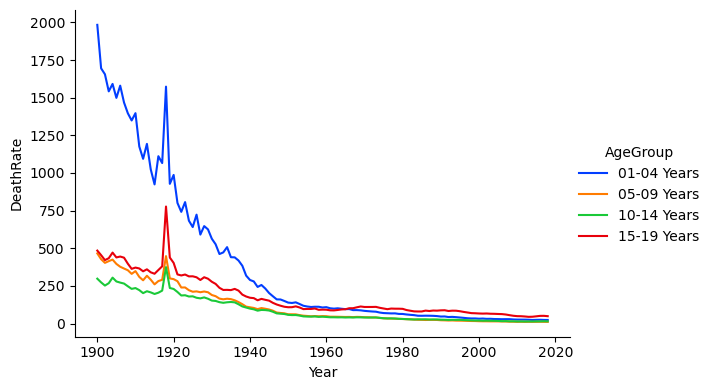

In [292]:
sns.relplot(data=mortality_data, kind='line',
x='Year', y='DeathRate', hue='AgeGroup', palette='bright', height=4, aspect=1.5)


In [293]:
#### Reload the data

In [294]:
mortality2clean = pd.read_csv('../data/mymortality-messy.csv')
mortality2clean.columns = mortality2clean.columns.str.replace(" ", "")
mortality2clean.AgeGroup = mortality2clean.AgeGroup.replace( {'1-4 Years':'01-04 Years','5-9 Years':'05-09 Years'})
mortality2clean = mortality2clean.drop_duplicates(keep='first')
mortality2clean = mortality2clean.drop(columns=['CurrentDate'])

mortality2clean.head(20)

#mortality2clean[['Year','DeathRate']] = mortality2clean[['Year','DeathRate']].interpolate()
#mortality2clean.head(4)

,Year,AgeGroup,DeathRate
0,1900,1-4 years,1983.8
1,1901,01-04 Years,1695
2,1902,01-04 Years,1655.7
3,1903,01-04 Years,1542.1
4,1904,01-04 Years,1591.5
5,1905,01-04 Years,1498.9
6,1906,01-04 Years,1580
7,1907,01-04 Years,1468.3
8,1908,01-04 Years,1396.8
9,1909,01-04 Years,NaN


In [295]:
mortality2clean[mortality2clean.DeathRate.isnull()]

,Year,AgeGroup,DeathRate
9,1909,01-04 Years,NaN
19,1919,01-04 Years,NaN
29,1929,01-04 Years,NaN
39,1939,01-04 Years,NaN
49,1949,01-04 Years,NaN


In [296]:
mortality2clean[['Year','DeathRate']] = mortality2clean[['Year','DeathRate']].interpolate()

#### But it didn't work

In [297]:
mortality2clean.loc[[9,19,29,39,49]]

,Year,AgeGroup,DeathRate
9,1909,01-04 Years,NaN
19,1919,01-04 Years,NaN
29,1929,01-04 Years,NaN
39,1939,01-04 Years,NaN
49,1949,01-04 Years,NaN


#### DeathRate needs to be float64 for numeric operations 
- Remember we were not able to select rows based on a deathrate over 1000
- Time to fix that

In [298]:
mortality2clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 479 entries, 0 to 482
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       479 non-null    int64 
 1   AgeGroup   479 non-null    object
 2   DeathRate  474 non-null    object
dtypes: int64(1), object(2)
memory usage: 31.1+ KB
